# Week 3 — Agentic Wallet Scoring Model

**Goal:** Train a model that outputs an agent-likelihood score (0–100) for any Base wallet.

## Pipeline
1. Load features + labels from Postgres
2. Random Forest baseline → ROC-AUC + recall@k
3. XGBoost → compare vs RF
4. SHAP feature importance

## Label encoding
| Label | y | Note |
|---|---|---|
| agent_virtuals | 1 | Virtuals ERC-6551 TBA |
| agent_acp | 1 | ACP Memo ≥1000 |
| eoa_sampled | 0 | Random active EOA |
| mev_bot | 0 | High-density same-block sender |

> **PU Learning caveat:** eoa_sampled and mev_bot are "reliable negatives", not a random unlabeled sample. This is a pragmatic approximation of PU learning — document this limitation.

In [12]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import roc_auc_score, RocCurveDisplay

from src.models.train import (
    load_data, train_rf, train_xgb,
    print_metrics, recall_at_k, FEATURE_COLS
)
from sklearn.model_selection import train_test_split

shap.initjs()

## 1. Load Data

In [13]:
df = load_data()
print(f"Total wallets : {len(df)}")
print(f"Agents  (y=1) : {df['y'].sum()}")
print(f"Non-agents (y=0): {(df['y']==0).sum()}")
df.groupby('label')['y'].count()

Total wallets : 3351
Agents  (y=1) : 1606
Non-agents (y=0): 1745


label
agent_acp         1606
agent_virtuals    1220
eoa_sampled        500
mev_bot             25
Name: y, dtype: int64

## 2. Feature Distribution by Label

Quick sanity check — do agents and non-agents look different?

In [14]:
df.groupby('label')[FEATURE_COLS].median().T

label,agent_acp,agent_virtuals,eoa_sampled,mev_bot
transfer_total,74.000000,7.000000,9.000000,50.000000
transfer_out,10.000000,0.000000,3.000000,0.000000
transfer_in,19.000000,7.000000,6.000000,48.000000
active_days,10.000000,5.000000,3.000000,17.000000
active_hours,14.000000,4.500000,4.000000,15.000000
hour_entropy,2.293868,0.962561,1.263654,2.461913
weekend_ratio,0.285714,0.038462,0.200000,0.200000
night_ratio,0.026316,0.038462,0.111111,0.215686
inter_tx_cv,6.945759,1.324445,1.767961,3.430433
burstiness,0.748293,0.139580,0.277446,0.548577


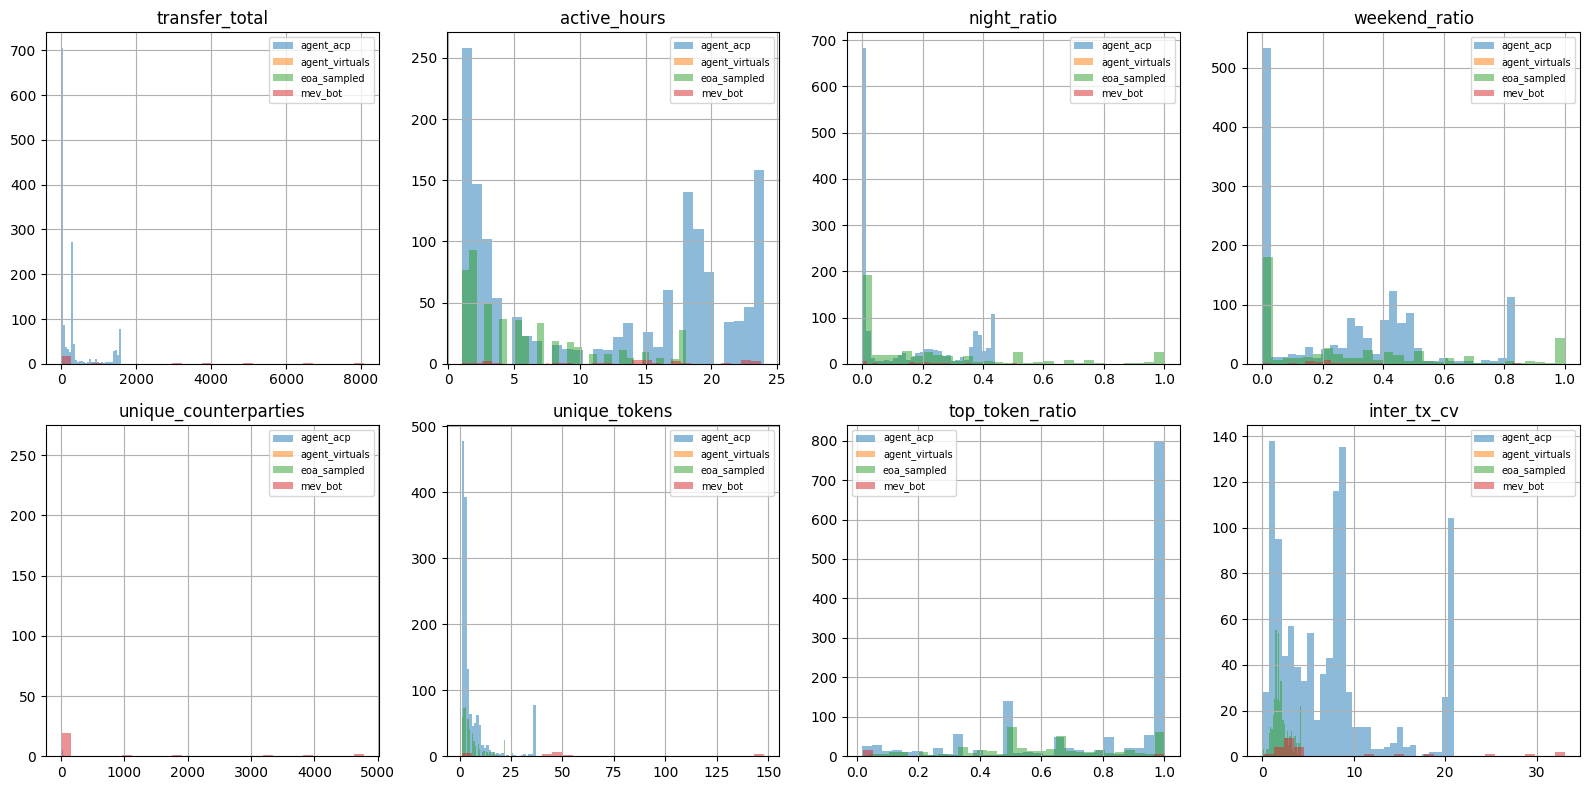

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
plot_cols = ['transfer_total', 'active_hours', 'night_ratio',
             'weekend_ratio', 'unique_counterparties', 'unique_tokens',
             'top_token_ratio', 'inter_tx_cv']

for ax, col in zip(axes, plot_cols):
    for label, grp in df.groupby('label'):
        grp[col].dropna().clip(upper=grp[col].quantile(0.95)).hist(
            ax=ax, alpha=0.5, label=label, bins=30
        )
    ax.set_title(col)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 3. Train / Test Split

In [16]:
X = df[FEATURE_COLS]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.2%}")

Train: 2680  |  Test: 671
Train positive rate: 47.91%


## 4. Random Forest Baseline

In [17]:
rf = train_rf(X_train, y_train)
rf_scores = rf.predict_proba(rf._imputer.transform(X_test))[:, 1]
print_metrics('Random Forest', y_test, rf_scores)


── Random Forest ──
  ROC-AUC : 0.9460
  recall@50  : 0.155
  recall@100 : 0.311
  recall@200 : 0.615
  recall@500 : 0.953


## 5. XGBoost

In [18]:
xgb_model = train_xgb(X_train, y_train)
xgb_scores = xgb_model.predict_proba(X_test)[:, 1]
print_metrics('XGBoost', y_test, xgb_scores)


── XGBoost ──
  ROC-AUC : 0.9428
  recall@50  : 0.155
  recall@100 : 0.311
  recall@200 : 0.609
  recall@500 : 0.963


## 6. ROC Curve Comparison

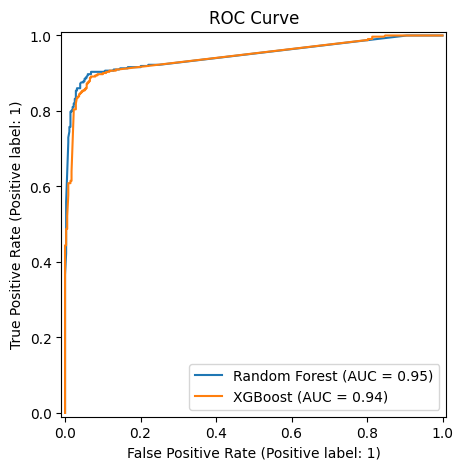

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, rf_scores, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_scores, name='XGBoost', ax=ax)
ax.set_title('ROC Curve')
plt.show()

## 7. SHAP Feature Importance (XGBoost)

SHAP tells us **why** the model gave each wallet its score.
Each bar = average absolute contribution to the prediction.

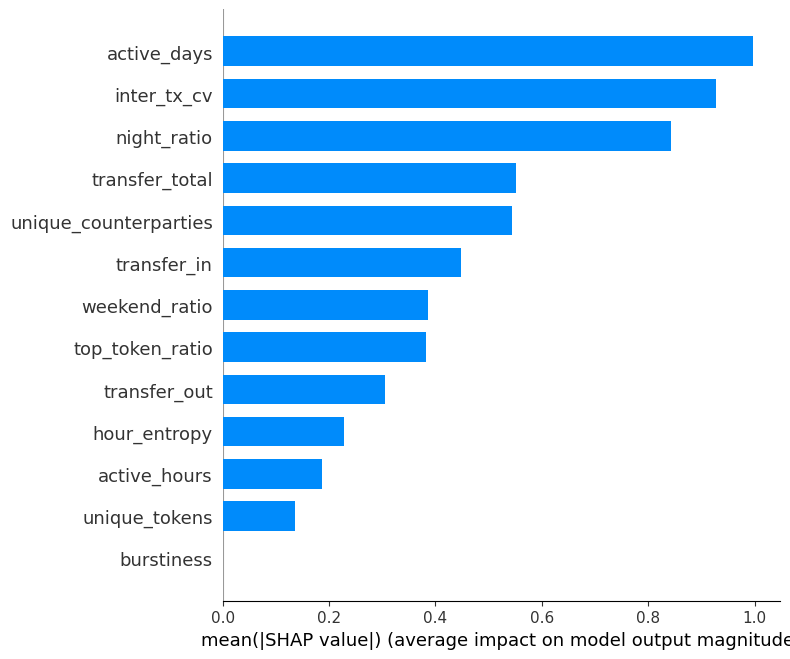

In [20]:
explainer   = shap.TreeExplainer(xgb_model)
X_test_imp  = X_test.fillna(X_test.median())
shap_values = explainer.shap_values(X_test_imp)

shap.summary_plot(shap_values, X_test_imp, plot_type='bar', show=True)

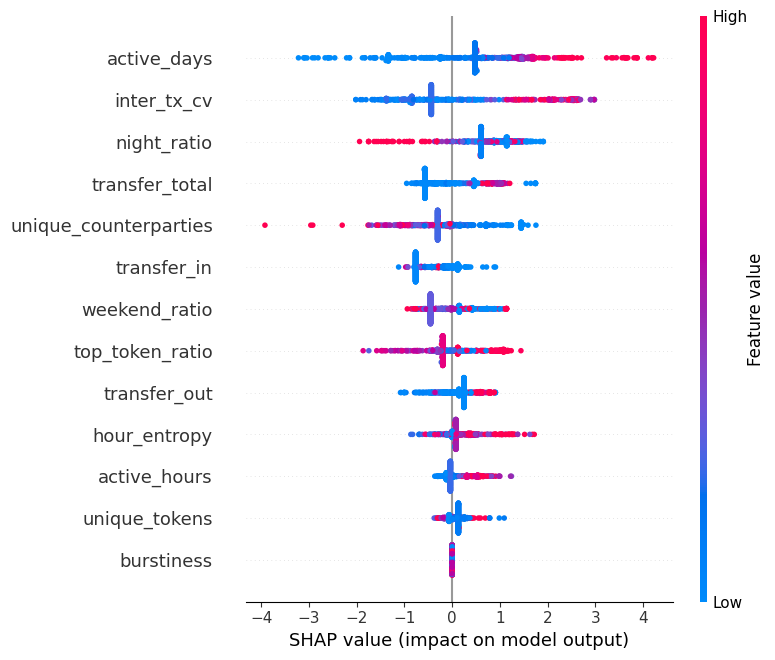

In [21]:
# Beeswarm plot — shows direction of each feature's effect
shap.summary_plot(shap_values, X_test_imp, show=True)

## 8. Score Distribution by Label

Sanity check: agents should score high, non-agents should score low.

In [22]:
results = X_test.copy()
results['label']     = df.loc[X_test.index, 'label'].values
results['xgb_score'] = (xgb_scores * 100).round(1)

results.groupby('label')['xgb_score'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
agent_acp,322.0,86.89,26.57,4.6,92.2,98.35,99.90,100.0
agent_virtuals,227.0,12.18,4.21,11.9,11.9,11.90,11.90,75.3
eoa_sampled,119.0,24.37,32.23,0.1,1.4,6.20,36.35,99.0
mev_bot,3.0,7.83,12.53,0.6,0.6,0.60,11.45,22.3
